# Sequências

**Módulo:** 03 – Progressões, Matrizes e Sistemas Lineares

**Pré-requisitos:** laços de repetição e definição de funções em Python, vistos em [00_fundamentos_e_python/](../00_fundamentos_e_python/) (`00_introducao_python.ipynb`); e a noção de função, domínio e imagem, vista em [`0105a_funcoes.ipynb`](../01_conjuntos_e_funcoes/0105a_funcoes.ipynb)

**Objetivos de aprendizagem:**
- Compreender uma sequência como uma função cujo domínio está nos números naturais (ou num subconjunto inicial deles).
- Diferenciar sequências finitas de infinitas, reconhecendo essa diferença em exemplos concretos.
- Determinar se duas sequências são iguais, comparando domínio e termo a termo.
- Encontrar e aplicar a lei de formação de uma sequência, tanto na forma explícita quanto na recursiva.

**Tempo estimado:** 45 a 60 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/03_progressoes_matrizes_e_sistemas_lineares/0301a_sequencias.ipynb)

📖 **Leitura complementar geral do notebook:** [Sequência (matemática)](https://pt.wikipedia.org/wiki/Sequ%C3%AAncia_(matem%C3%A1tica)) · [Sequência de Fibonacci](https://pt.wikipedia.org/wiki/Sequ%C3%AAncia_de_Fibonacci)

## Figuras de pontos: dá pra prever o futuro?

Olhe estas quatro figuras, feitas empilhando bolinhas em fileiras que crescem uma a uma, formando um triângulo:

- **Figura 1:** 1 bolinha
- **Figura 2:** 3 bolinhas (uma fileira de 1 e outra de 2)
- **Figura 3:** 6 bolinhas (fileiras de 1, 2 e 3)
- **Figura 4:** 10 bolinhas (fileiras de 1, 2, 3 e 4)

**Antes de continuar, arrisque um palpite:** quantas bolinhas terá a Figura 5? E a Figura 10? Guarde os seus palpites — vamos responder as duas perguntas ao longo deste notebook, usando exatamente a ferramenta que estamos prestes a estudar: **sequências**.

📖 **Leitura complementar:** [Número triangular](https://pt.wikipedia.org/wiki/N%C3%BAmero_triangular)

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


def numero_triangular(n: int) -> int:
    """Calcula o n-ésimo número triangular: 1 + 2 + ... + n."""
    return n * (n + 1) // 2

## 1. O que é uma Sequência

Cada figura de bolinhas do gancho tem uma quantidade de bolinhas que depende só da posição da figura: a 1ª tem 1, a 2ª tem 3, a 3ª tem 6, e assim por diante. Isso é exatamente o que é uma **sequência**: cada posição n (um número natural) é associada a um único valor.

📌 **Definição formal:** uma **sequência** é uma função a: ℕ* → ℝ (ou de um subconjunto inicial de ℕ*, no caso finito), que associa a cada índice n um único termo, indicado por **aₙ** (lê-se "a índice n" ou "a-ene"). Escrevemos a sequência inteira como (a₁, a₂, a₃, ..., aₙ, ...), ou simplesmente (aₙ).

- a₁, a₂, a₃, ... são os **termos** da sequência.
- n é o **índice** (a posição do termo).
- aₙ é o **termo geral**, escrito em função da posição n.

**Sequência finita × infinita:**
- Uma sequência é **finita** quando seu domínio é um conjunto {1, 2, ..., k} — ela tem um último termo.
- Uma sequência é **infinita** quando seu domínio é todo ℕ* — não existe "o último termo".

⚠️ Essa diferença vai importar mais à frente: quando estudarmos progressões geométricas, o comportamento de uma PG finita e de uma PG infinita (por exemplo, a soma dos seus termos) é bem diferente.

📎 **Conexão:** o conceito de função — domínio, contradomínio, imagem — que você viu em [`0105a_funcoes.ipynb`](../01_conjuntos_e_funcoes/0105a_funcoes.ipynb) é exatamente a base formal de sequência: aqui o domínio é apenas (um subconjunto de) ℕ*, em vez de ℝ.

Como exemplo, vamos representar a sequência aₙ = n² de três formas: algébrica (a fórmula), numérica (uma tabela) e gráfica (pontos isolados, não uma curva).

,n,a_n = n²
0,1,1
1,2,4
2,3,9
3,4,16
4,5,25
5,6,36
6,7,49


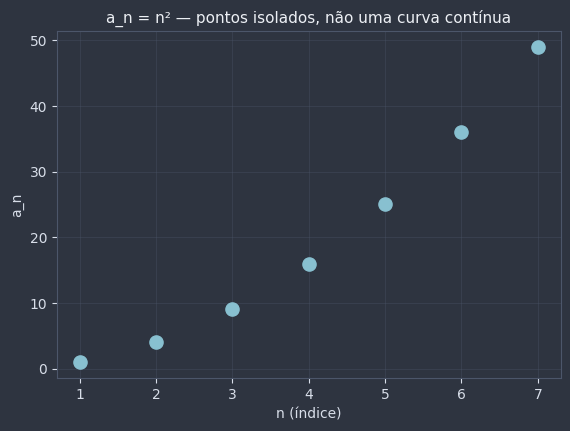

In [2]:
def a_quadrado(n):
    """Lei de formação: a_n = n ao quadrado."""
    return n**2


indices = np.arange(1, 8)
termos = a_quadrado(indices)

tabela_quadrados = pd.DataFrame({"n": indices, "a_n = n²": termos})
display(tabela_quadrados)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.scatter(indices, termos, s=90, color=COR_PONTO, zorder=3)
ax.set_xlabel("n (índice)", color=NORD_TEXTO_SEC)
ax.set_ylabel("a_n", color=NORD_TEXTO_SEC)
ax.set_xticks(indices)
ax.set_title("a_n = n² — pontos isolados, não uma curva contínua", color=NORD_TEXTO, fontsize=11)
plt.show()

**Pergunta de checagem:** por que o gráfico de uma sequência é feito só de pontos separados, e não de uma linha contínua ligando esses pontos?

🎯 **Aplicação prática:** o saldo de uma conta poupança, registrado uma vez por mês, é uma sequência — só faz sentido falar no saldo do mês 3 ou do mês 4, nunca "no mês 3,5".

## 2. Igualdade de Sequências

📌 **Definição formal:** duas sequências (aₙ) e (bₙ) são **iguais** quando têm o **mesmo domínio** e aₙ = bₙ para **todo** n desse domínio.

Isso parece óbvio, mas duas sequências podem gerar os mesmos números e, mesmo assim, não serem iguais — ou parecer diferentes à primeira vista e serem exatamente a mesma sequência.

⚠️ **Erro comum:** achar que duas sequências com os mesmos números, mas em ordem diferente (ou com os índices deslocados), são iguais. (1, 2, 3, 4) e (4, 3, 2, 1) têm os mesmos quatro números, mas a₁ ≠ b₁ (1 ≠ 4) — são sequências diferentes, porque a posição de cada termo importa.

In [3]:
# Comparando duas sequências termo a termo
seq_a = np.array([1, 2, 3, 4])
seq_b = np.array([4, 3, 2, 1])
seq_c = np.array([1, 2, 3, 4])

print("seq_a == seq_b, termo a termo:", seq_a == seq_b)
print("seq_a é igual a seq_b?", np.array_equal(seq_a, seq_b))
print()
print("seq_a == seq_c, termo a termo:", seq_a == seq_c)
print("seq_a é igual a seq_c?", np.array_equal(seq_a, seq_c))

seq_a == seq_b, termo a termo: [False False False False]
seq_a é igual a seq_b? False

seq_a == seq_c, termo a termo: [ True  True  True  True]
seq_a é igual a seq_c? True


Duas leis de formação diferentes também podem gerar a mesma sequência — a igualdade depende dos **valores**, não da forma como a fórmula está escrita.

In [4]:
# Duas leis diferentes que geram a MESMA sequência
def formula_1(n):
    return n**2 + n


def formula_2(n):
    return n * (n + 1)


indices = np.arange(1, 6)
print("formula_1:", formula_1(indices))
print("formula_2:", formula_2(indices))
print("são iguais?", np.array_equal(formula_1(indices), formula_2(indices)))

formula_1: [ 2  6 12 20 30]
formula_2: [ 2  6 12 20 30]
são iguais? True


**Pergunta de checagem:** se duas sequências têm os cinco primeiros termos iguais, elas são necessariamente a mesma sequência? (pense no caso de domínio infinito, com termos seguintes ainda não comparados)

## 3. Lei de Formação Explícita

📌 **Definição formal:** a **lei de formação explícita** de uma sequência dá aₙ diretamente em função de n, sem precisar conhecer nenhum termo anterior.

Exemplo: aₙ = 2n − 1 gera a sequência dos números ímpares (1, 3, 5, 7, 9, ...).

🕹️ **Widget interativo:** mexa no slider de n e observe o termo correspondente sendo calculado e destacado sobre o restante da sequência.

In [5]:
def a_impar(n):
    """Lei de formação explícita: a_n = 2n - 1 (números ímpares)."""
    return 2 * n - 1


def explorar_lei_explicita(n: int) -> None:
    indices_fundo = np.arange(1, 16)
    termos_fundo = a_impar(indices_fundo)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.scatter(indices_fundo, termos_fundo, s=50, color=NORD_LINHA, zorder=2)
    ax.scatter([n], [a_impar(n)], s=160, color=COR_ALERTA, zorder=4)
    ax.set_xlabel("n (índice)", color=NORD_TEXTO_SEC)
    ax.set_ylabel("a_n = 2n - 1", color=NORD_TEXTO_SEC)
    ax.set_title(f"a_{n} = 2·{n} - 1 = {a_impar(n)}", color=NORD_TEXTO, fontsize=11)
    plt.show()


widgets.interact(
    explorar_lei_explicita,
    n=widgets.IntSlider(value=1, min=1, max=15, step=1, description="n:"),
)

interactive(children=(IntSlider(value=1, description='n:', max=15, min=1), Output()), _dom_classes=('widget-in…

<function __main__.explorar_lei_explicita(n: int) -> None>

**Descobrindo o padrão — fechando o gancho:** volte às figuras de bolinhas do início do notebook. Elas formam a sequência (1, 3, 6, 10, ...), os **números triangulares**. Será que ela também tem uma lei de formação explícita, do tipo aₙ = c₂·n² + c₁·n?

🕹️ **Widget interativo:** ajuste os dois coeficientes até a coluna "seu palpite" bater com a coluna "a_n real" para todos os n da tabela.

In [6]:
def testar_lei_triangular(coef_n2: float, coef_n: float) -> None:
    indices = np.arange(1, 6)
    reais = np.array([numero_triangular(n) for n in indices])
    palpite = coef_n2 * indices**2 + coef_n * indices

    tabela = pd.DataFrame({
        "n": indices,
        "a_n real (bolinhas)": reais,
        "seu palpite": palpite,
    })
    display(tabela)

    if np.allclose(palpite, reais):
        print(f"✅ Acertou! a_n = {coef_n2:g}·n² + {coef_n:g}·n reproduz a sequência.")
        print(f"Pela lei descoberta, a Figura 10 teria {coef_n2 * 100 + coef_n * 10:.0f} bolinhas.")
    else:
        print("❌ Ainda não bate — ajuste os sliders.")


widgets.interact(
    testar_lei_triangular,
    coef_n2=widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.1, description="coef. de n²:"),
    coef_n=widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.1, description="coef. de n:"),
)

interactive(children=(FloatSlider(value=0.0, description='coef. de n²:', max=1.0), FloatSlider(value=0.0, desc…

<function __main__.testar_lei_triangular(coef_n2: float, coef_n: float) -> None>

📌 A lei de formação é aₙ = n(n+1)/2 — os **números triangulares**. Conferindo: a₁₀ = 10·11/2 = 55 bolinhas, exatamente o que o widget acima confirmou.

🕵️ **Curiosidade histórica:** conta-se que o próprio Gauss, ainda criança, teria usado essa mesma ideia — emparelhar o primeiro termo com o último — para somar rapidamente 1+2+...+100, resultado que é exatamente o número triangular a₁₀₀. Vamos reencontrar essa soma de forma mais geral quando estudarmos progressão aritmética, o próximo notebook do módulo.

**Pergunta de checagem:** duas leis de formação diferentes (dois polinômios diferentes em n, por exemplo) podem gerar exatamente os mesmos primeiros 5 termos e depois divergir? O que isso te diz sobre "adivinhar" uma lei olhando só para poucos termos?

🎯 **Aplicação prática:** o número de mensagens em um grupo que recebe sempre a mesma quantidade extra de mensagens por dia segue uma lei de formação explícita, do mesmo jeito que a sequência dos números ímpares.

## 4. Lei de Formação Recursiva

📌 **Definição formal:** numa **lei de formação recursiva** (ou de recorrência), cada termo é definido em função do(s) termo(s) **anterior(es)**, e não diretamente em função de n.

O exemplo mais famoso é a **sequência de Fibonacci**:

$$F_1 = 1, \quad F_2 = 1, \quad F_n = F_{n-1} + F_{n-2} \text{ para } n \geq 3$$

Diferente da lei explícita, aqui não dá para calcular F₁₀₀ sem antes conhecer F₉₉ e F₉₈.

,n,F_n
0,1,1
1,2,1
2,3,2
3,4,3
4,5,5
5,6,8
6,7,13
7,8,21
8,9,34
9,10,55


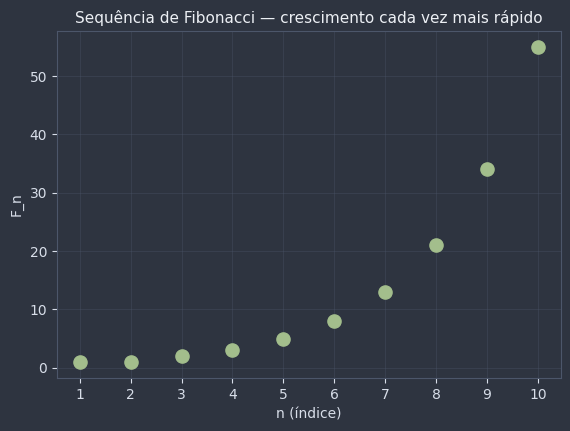

In [7]:
def fibonacci(n: int) -> int:
    """Calcula o n-ésimo termo de Fibonacci por recursão (F_1 = F_2 = 1)."""
    if n in (1, 2):
        return 1
    return fibonacci(n - 1) + fibonacci(n - 2)


indices = np.arange(1, 11)
termos_fib = [fibonacci(n) for n in indices]

tabela_fib = pd.DataFrame({"n": indices, "F_n": termos_fib})
display(tabela_fib)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.scatter(indices, termos_fib, s=90, color=COR_DESTAQUE, zorder=3)
ax.set_xlabel("n (índice)", color=NORD_TEXTO_SEC)
ax.set_ylabel("F_n", color=NORD_TEXTO_SEC)
ax.set_xticks(indices)
ax.set_title("Sequência de Fibonacci — crescimento cada vez mais rápido", color=NORD_TEXTO, fontsize=11)
plt.show()

🕵️ **Curiosidade histórica:** Fibonacci apresentou essa sequência na Europa em 1202, no livro *Liber Abaci*, a partir de um problema (fictício) sobre reprodução de coelhos. Mais tarde descobriu-se que a razão entre termos consecutivos (Fₙ₊₁/Fₙ) se aproxima cada vez mais de um número especial, a **razão áurea** φ ≈ 1,618... Ela também aparece na natureza — número de pétalas de muitas flores, disposição de sementes em girassóis, espirais de conchas. Vamos formalizar essa convergência quando estudarmos progressão geométrica e limites, mais à frente no curso.

🕹️ **Widget interativo:** mexa no slider da quantidade de termos e observe a sequência crescer cada vez mais rápido.

In [ ]:
def explorar_fibonacci(quantidade: int) -> None:
    indices = np.arange(1, quantidade + 1)
    termos = [fibonacci(n) for n in indices]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.scatter(indices, termos, s=70, color=COR_DESTAQUE, zorder=3)
    ax.set_xlabel("n (índice)", color=NORD_TEXTO_SEC)
    ax.set_ylabel("F_n", color=NORD_TEXTO_SEC)
    ax.set_title(f"Fibonacci até o {quantidade}º termo (F_{quantidade} = {termos[-1]})", color=NORD_TEXTO, fontsize=11)
    plt.show()


widgets.interact(
    explorar_fibonacci,
    quantidade=widgets.IntSlider(value=8, min=2, max=20, step=1, description="termos:"),
)

interactive(children=(IntSlider(value=8, description='termos:', max=20, min=2), Output()), _dom_classes=('widg…

<function __main__.explorar_fibonacci(quantidade: int) -> None>

⚠️ **Erro comum:** escrever uma função recursiva sem caso-base (ou com um caso-base que nunca é alcançado) causa **recursão infinita** — o programa chama a si mesmo para sempre, até estourar a pilha de chamadas (erro `RecursionError` em Python). Toda lei recursiva **precisa** de um ponto de partida direto (aqui, F₁ = F₂ = 1) que não dependa de mais nenhum termo anterior.

In [9]:
def fibonacci_sem_caso_base(n: int) -> int:
    # ERRO PROPOSITAL: falta o caso-base, então a recursão nunca para
    return fibonacci_sem_caso_base(n - 1) + fibonacci_sem_caso_base(n - 2)


try:
    fibonacci_sem_caso_base(5)
except RecursionError:
    print("❌ RecursionError: a função chamou a si mesma infinitas vezes, porque não tem caso-base.")

❌ RecursionError: a função chamou a si mesma infinitas vezes, porque não tem caso-base.


**Pergunta de checagem:** por que não dá para calcular F₅₀ diretamente a partir de uma fórmula fechada, sem conhecer (ou calcular) os termos anteriores, numa lei recursiva?

🎯 **Aplicação prática:** recorrências como a de Fibonacci aparecem em algoritmos de busca e em estruturas de dados (heaps de Fibonacci), além de servirem de base para modelos idealizados de crescimento populacional.

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Sequência | função aₙ com domínio em ℕ* (ou num subconjunto inicial dele) |
| Termos | a₁, a₂, a₃, ...; n = índice, aₙ = termo geral |
| Finita × infinita | domínio {1,...,k} (tem último termo) × domínio todo ℕ* |
| Igualdade de sequências | mesmo domínio E aₙ = bₙ para todo n |
| Erro comum | os mesmos números em ordem diferente ≠ a mesma sequência |
| Lei de formação explícita | aₙ em função direta de n (ex: aₙ = 2n − 1) |
| Lei de formação recursiva | aₙ em função de termo(s) anterior(es) (ex: Fibonacci, Fₙ = Fₙ₋₁ + Fₙ₋₂) |
| Números triangulares | aₙ = n(n+1)/2 |
| Cuidado com recursão | sempre defina um caso-base, ou a recursão nunca termina |

## Exercícios

**Básico**
1. Calcular os termos de uma sequência dada por uma lei explícita.
2. Identificar se uma sequência descrita em palavras é finita ou infinita.

**Intermediário**
3. Verificar se duas sequências dadas por fórmulas diferentes são iguais.
4. Encontrar a lei de formação explícita a partir dos primeiros termos e usá-la para prever um termo distante.

**Desafio**
5. Implementar e analisar a sequência de Lucas, uma recorrência diferente de Fibonacci.
6. Comparar recursão pura com uma versão iterativa, discutindo o custo computacional de calcular termos distantes.

Gabarito completo com resolução comentada em [`0301b_sequencias_gabarito.ipynb`](0301b_sequencias_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: dada a lei de formação a_n = 3n + 1, calcule os
# primeiros 5 termos (n de 1 a 5). Preencha termos_ex1 com uma lista (ou
# array) com os 5 valores, na ordem de n=1 até n=5.
termos_ex1 = ...

print(termos_ex1)

In [ ]:
# Verificação
assert list(termos_ex1) == [4, 7, 10, 13, 16], (
    "Tente de novo, revise: a_n = 3n + 1; calcule para n=1,2,3,4,5 "
    "(seção 3 - Lei de Formação Explícita)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: para cada situação abaixo, diga se a sequência
# descrita é INFINITA (True) ou FINITA (False). Preencha eh_infinita_ex2
# com uma lista de 4 booleanos, na mesma ordem das situações.
# a) o número de dias de fevereiro em cada ano, de 2000 até 2030
# b) os números pares positivos: 2, 4, 6, 8, ...
# c) as notas de um aluno nas 10 provas do ano letivo
# d) os termos da sequência de Fibonacci
eh_infinita_ex2 = ...

print(eh_infinita_ex2)

In [ ]:
# Verificação
assert eh_infinita_ex2 == [False, True, False, True], (
    "Tente de novo, revise: uma sequência é finita quando tem um último "
    "termo (domínio {1,...,k}); é infinita quando o domínio é todo N* "
    "(seção 1 - O que é uma Sequência)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: as duas leis abaixo definem sequências (para
# n de 1 a 6). Calcule os termos de cada uma e diga se as duas sequências
# são IGUAIS (mesmo domínio e mesmos termos). Preencha
# sequencias_iguais_ex3 com True ou False.
# a_n = (n+1)^2 - (2n+1)
# b_n = n^2
indices_ex3 = np.arange(1, 7)
termos_a_ex3 = ...
termos_b_ex3 = ...
sequencias_iguais_ex3 = ...

print(termos_a_ex3, termos_b_ex3, sequencias_iguais_ex3)

In [ ]:
# Verificação
assert np.array_equal(termos_a_ex3, (indices_ex3 + 1) ** 2 - (2 * indices_ex3 + 1)), (
    "Tente de novo, revise termos_a_ex3: substitua n em (n+1)² - (2n+1) "
    "para n=1,...,6 (seção 2 - Igualdade de Sequências)."
)
assert np.array_equal(termos_b_ex3, indices_ex3**2), (
    "Tente de novo, revise termos_b_ex3: b_n = n² (seção 2 - Igualdade "
    "de Sequências)."
)
assert sequencias_iguais_ex3, (
    "Tente de novo: (n+1)² - (2n+1) simplifica algebricamente para n², "
    "então as duas sequências têm os mesmos termos em todo o domínio "
    "(seção 2 - Igualdade de Sequências)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: a sequência abaixo começa com os termos
# 5, 8, 11, 14, 17, ... Descubra a lei de formação explícita a_n (em
# função de n) e use-a para calcular o 10º termo. Preencha a10_ex4.
a10_ex4 = ...

print(a10_ex4)

In [ ]:
# Verificação
assert a10_ex4 == 32, (
    "Tente de novo, revise: cada termo aumenta 3 em relação ao anterior "
    "e o primeiro termo é 5, então a_n = 3n + 2; a_10 = 3*10+2 = 32 "
    "(seção 3 - Lei de Formação Explícita)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: a sequência de Lucas é definida de forma
# recursiva, parecida com Fibonacci, mas com um começo diferente:
# L_1 = 2, L_2 = 1, e L_n = L_(n-1) + L_(n-2) para n >= 3. Implemente a
# função lucas(n) de forma recursiva e calcule os 10 primeiros termos
# (n=1 até 10) na lista termos_lucas_ex5.
def lucas(n: int) -> int:
    ...


termos_lucas_ex5 = ...

print(termos_lucas_ex5)

In [ ]:
# Verificação
assert [lucas(n) for n in range(1, 11)] == [2, 1, 3, 4, 7, 11, 18, 29, 47, 76], (
    "Tente de novo, revise a função lucas: caso-base L_1=2, L_2=1; para "
    "n>=3, L_n = L_(n-1) + L_(n-2) (seção 4 - Lei de Formação Recursiva)."
)
assert termos_lucas_ex5 == [lucas(n) for n in range(1, 11)], (
    "Tente de novo, revise: calcule termos_lucas_ex5 chamando lucas(n) "
    "para n de 1 até 10 (seção 4 - Lei de Formação Recursiva)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6: a função fibonacci(n) do notebook principal usa
# recursão pura, sem guardar resultados intermediários (sem memoização) -
# isso faz o número de chamadas crescer exponencialmente com n, tornando
# o cálculo de termos distantes (como n=30) muito lento. Implemente uma
# versão ITERATIVA fibonacci_iterativo(n) (com um laço, sem recursão) que
# calcule o mesmo valor de forma muito mais rápida, e use-a para calcular
# o 30º termo em fib30_iterativo_ex6.
def fibonacci_iterativo(n: int) -> int:
    ...


fib30_iterativo_ex6 = ...

print(fib30_iterativo_ex6)

In [ ]:
# Verificação
assert fibonacci_iterativo(10) == fibonacci(10), (
    "Tente de novo, revise fibonacci_iterativo: ela deve calcular o "
    "mesmo valor que a versão recursiva, mas usando um laço em vez de "
    "chamadas recursivas (seção 4 - Lei de Formação Recursiva)."
)
assert fib30_iterativo_ex6 == 832040, (
    "Tente de novo, revise: o 30º termo de Fibonacci (F_1=F_2=1) vale "
    "832040 - confira o laço de fibonacci_iterativo (seção 4 - Lei de "
    "Formação Recursiva)."
)
print("Certo!")

## Glossário do bloco

| Termo | Definição |
|---|---|
| Sequência | função com domínio em ℕ* (ou num subconjunto inicial dele) |
| Termo geral | aₙ, o valor da sequência na posição n, escrito em função de n |
| Índice | a posição n de um termo dentro da sequência |
| Sequência finita | domínio {1, 2, ..., k}; tem um último termo |
| Sequência infinita | domínio todo ℕ*; não tem último termo |
| Lei de formação explícita | expressão que dá aₙ diretamente em função de n |
| Lei de formação recursiva (recorrência) | expressão que dá aₙ em função de termo(s) anterior(es) |
| Caso-base | o(s) termo(s) inicial(is) de uma recorrência, definido(s) sem depender de termos anteriores |
| Número triangular | aₙ = n(n+1)/2, soma dos n primeiros números naturais |

## Conexões

**Isso depende de:**
- [`00_introducao_python.ipynb`](../00_fundamentos_e_python/00_introducao_python.ipynb) (laços de repetição, definição de funções em Python)
- [`0105a_funcoes.ipynb`](../01_conjuntos_e_funcoes/0105a_funcoes.ipynb) (função, domínio e imagem)

**Isso será usado em:**
- [`0302a_progressao_aritmetica.ipynb`](0302a_progressao_aritmetica.ipynb) (sequência com razão constante entre termos consecutivos — caso particular de lei de formação explícita)
- 📌 Progressão Geométrica (sequência com razão constante multiplicativa — retoma a razão áurea de Fibonacci)
- [`13_algebra_linear/`](../13_algebra_linear/) (sequências recursivas reaparecem em relações de recorrência e autovalores)